¿Sería mejor diferenciar los vuelos para el modelo?
Si quieres un modelo que prediga precios reales → NO

No necesitas diferenciar:

- “1-stop via Hyderabad”
- “1-stop via Kolkata”

Porque:

- No afecta al precio
- No aporta información útil
- Añade ruido
- Aumenta la dimensionalidad
- Empeora el modelo

Las aerolíneas no fijan precios según la ciudad de escala.
Fijan precios según:

- número de escalas
- duración
- demanda
- antelación
- competencia
- franja horaria

1. ¿Por qué fijar una fecha artificial NO daña el proyecto?
Porque en el webscraping no existía la fecha real de consulta, y sin esa fecha:

no puedes calcular la anticipación

no puedes modelar la dinámica temporal

no puedes explicar por qué un vuelo vale 50€ hoy y 200€ mañana

el modelo no aprende nada útil

La anticipación es la variable más importante en pricing aéreo.
Sin ella, el modelo sería ciego.

Por eso fijar una fecha artificial es la única forma correcta de reconstruir esa variable.

2. ¿Es suficiente para un proyecto bueno?
- Sí, totalmente suficiente.
- Es una práctica habitual en proyectos reales.
- Es defendible técnicamente.
- Es coherente con el plan de negocio.

De hecho, en consultoría y data science se hace constantemente cuando:

- falta la fecha de scraping
- falta la fecha de compra
- falta la fecha de registro
- los datos vienen de APIs sin timestamp
- Lo importante no es la fecha exacta, sino la consistencia.

3. ¿Por qué el 11 de febrero es válido?

Porque:

- es una fecha fija

- es anterior a los vuelos del dataset

- permite calcular la anticipación

- no introduce sesgos

- no afecta a la comparación entre aerolíneas

- Si hubieras elegido el 10, el 12 o el 20, el modelo habría funcionado igual.
- Lo importante es que sea una fecha única y coherente.

⭐ 1. ¿Por qué dos filas se vuelven iguales después de las transformaciones?
Porque cuando haces:

limpieza

conversión de fechas

extracción de variables (mes, día, antelación…)

codificación de aerolínea, origen, destino

eliminación de columnas irrelevantes

…te quedas solo con las variables que realmente explican el precio.

Si dos vuelos tienen:

misma aerolínea

mismo origen

mismo destino

misma duración

misma clase

misma fecha de vuelo

misma antelación

mismas escalas

Entonces son el mismo vuelo desde el punto de vista del modelo, aunque tengan distinto número de vuelo.

⭐ 2. ¿Por qué flight es lo único que los diferencia?
Porque flight es un identificador, no una característica del vuelo.

In [1]:
import matplotlib.pyplot as plt
import joblib
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

from scipy import stats

import bootcampviztools as bt

pd.options.mode.copy_on_write = True

Este Dataset no lo pondremos en el archivo defintivo: 

In [2]:
df_limpio = pd.read_csv("../data/Clean_Dataset.csv")
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [3]:
df_limpio.head(30)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [4]:
df_limpio.duplicated().sum()


np.int64(0)

In [5]:
df_limpio[df_limpio.duplicated(keep=False)]


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


**ECONOMY**

In [6]:
df_economy = pd.read_csv("../data/economy.csv")
df_economy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


In [7]:
df_economy.head(10)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"
5,11-02-2022,Vistara,UK,945,11:40,Delhi,02h 20m,non-stop,14:00,Mumbai,"5,955"
6,11-02-2022,Vistara,UK,927,09:30,Delhi,02h 05m,non-stop,11:35,Mumbai,"6,060"
7,11-02-2022,Vistara,UK,951,14:20,Delhi,02h 10m,non-stop,16:30,Mumbai,"6,060"
8,11-02-2022,GO FIRST,G8,334,08:00,Delhi,02h 10m,non-stop,10:10,Mumbai,"5,954"
9,11-02-2022,GO FIRST,G8,336,14:20,Delhi,02h 15m,non-stop,16:35,Mumbai,"5,954"


In [8]:
df_economy.duplicated().sum()


np.int64(2)

In [9]:
df_economy[df_economy.duplicated(keep=False)]


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
516,14-02-2022,Air India,AI,807,17:20,Delhi,15h 15m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,08:35,Mumbai,"12,150"
563,14-02-2022,Air India,AI,807,17:20,Delhi,15h 15m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,08:35,Mumbai,"12,150"
6080,13-03-2022,Air India,AI,475,13:00,Delhi,24h 35m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,13:35,Mumbai,"4,780"
6181,13-03-2022,Air India,AI,475,13:00,Delhi,24h 35m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,13:35,Mumbai,"4,780"


In [10]:
df_eco=df_economy.copy()

**Tratamiento de economy**

Sí, tiene bastante sentido —y de hecho es una práctica común— que una agencia de viajes intente predecir los precios de las aerolíneas. No porque puedan adivinar el futuro, sino porque anticipar tendencias les da ventajas competitivas muy claras.

Por qué tiene sentido que lo hagan
Aquí van las razones más sólidas:

📈 1. Optimizar cuándo comprar inventario
Muchas agencias compran cupos o bloquean tarifas. Si pueden estimar cuándo los precios subirán o bajarán, pueden:

Comprar más barato.

Reducir riesgo de quedarse con plazas caras.

Mejorar márgenes sin subir precios al cliente.

💼 2. Ofrecer mejores precios a los clientes
Si una agencia sabe que una ruta suele bajar los martes o subir cuando se acerca un feriado, puede:

Recomendar el mejor momento para reservar.

Crear campañas más inteligentes.

Diferenciarse de la competencia.

🤖 3. Modelos predictivos basados en datos reales
Las aerolíneas usan yield management, un sistema dinámico que ajusta precios según:

Demanda.

Antelación.

Temporada.

Competencia.

Eventos especiales.

Aunque es complejo, los patrones existen, y una agencia con datos históricos puede entrenar modelos para detectar tendencias.

🧠 4. Mejorar la planificación interna
Predicciones razonables ayudan a:

Planificar ventas.

Ajustar comisiones.

Negociar con proveedores.

Diseñar paquetes turísticos más rentables.

¿Qué tan precisas pueden ser estas predicciones?
Aquí viene la parte interesante:
No pueden ser perfectas, porque las aerolíneas cambian precios de forma muy dinámica y con información que solo ellas conocen.

Pero sí pueden ser útiles, como una brújula: no te dice el camino exacto, pero te orienta.

**Simplificar airline**

In [11]:
df_eco.airline.value_counts(ascending= False)

airline
Vistara      67270
Air India    47996
Indigo       43120
GO FIRST     23177
AirAsia      16098
SpiceJet      9011
StarAir         61
Trujet          41
Name: count, dtype: int64

In [12]:
df_eco.airline.value_counts(normalize= True, ascending= False)

airline
Vistara      0.325331
Air India    0.232118
Indigo       0.208537
GO FIRST     0.112089
AirAsia      0.077853
SpiceJet     0.043579
StarAir      0.000295
Trujet       0.000198
Name: proportion, dtype: float64

In [13]:
otras = ["AirAsia", "SpiceJet", "StarAir","Trujet"]

df_eco["airline"] = df_eco["airline"].replace(otras, "Otra")

In [14]:
df_eco.airline.value_counts(normalize= True, ascending= False)

airline
Vistara      0.325331
Air India    0.232118
Indigo       0.208537
Otra         0.121925
GO FIRST     0.112089
Name: proportion, dtype: float64

Creo columna flight:

- ch_code → código de aerolínea (SG, UK, I5…)
- num_code → número de vuelo

In [15]:
df_eco['flight'] = df_eco['ch_code'] + df_eco['num_code'].astype(str)

**Convertir price a número**

In [16]:
df_eco['price'] = df_eco['price'].str.replace(',', '').astype(int)

**Limpiar time_taken**

In [17]:
df_eco['time_taken'].isna().sum()


np.int64(0)

In [18]:
df_eco[df_eco['time_taken'].isna()]


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight


Convierto todo a horas, pero no a “horas enteras”, sino a horas en formato decimal, que es lo que un modelo de machine learning puede entender y usar de forma correcta.

In [19]:
import re
import numpy as np

def convert_duration(x):
    if pd.isna(x):
        return np.nan
    
    # Buscar horas
    h = re.search(r'(\d+)h', x)
    hours = int(h.group(1)) if h else 0
    
    # Buscar minutos
    m = re.search(r'(\d+)m', x)
    minutes = int(m.group(1)) if m else 0
    
    return hours + minutes/60

df_eco['duration'] = df_eco['time_taken'].apply(convert_duration)


**Convertir horas (dep_time y arr_time)**

Convertir dep_time y arr_time a datetime
- Tus horas vienen como strings "18:55", "06:20"…

In [20]:
#Primero las convertimos a datetime:
df_eco['dep_time'] = pd.to_datetime(df_eco['dep_time'], format='%H:%M')
df_eco['arr_time'] = pd.to_datetime(df_eco['arr_time'], format='%H:%M')
#Ahora extraemos la hora numérica (muy útil para ML):
df_eco['dep_hour'] = df_eco['dep_time'].dt.hour
df_eco['arr_hour'] = df_eco['arr_time'].dt.hour


In [21]:
df_eco['dep_hour'].unique()


array([18,  6,  4, 10,  8, 11,  9, 14, 15,  7, 12, 19,  5, 17, 13, 16, 21,
       20, 22, 23,  2,  0,  1,  3], dtype=int32)

In [22]:
sorted(df_eco['dep_hour'].unique())


[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9),
 np.int32(10),
 np.int32(11),
 np.int32(12),
 np.int32(13),
 np.int32(14),
 np.int32(15),
 np.int32(16),
 np.int32(17),
 np.int32(18),
 np.int32(19),
 np.int32(20),
 np.int32(21),
 np.int32(22),
 np.int32(23)]

In [23]:
sorted(df_eco['arr_hour'].unique())


[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9),
 np.int32(10),
 np.int32(11),
 np.int32(12),
 np.int32(13),
 np.int32(14),
 np.int32(15),
 np.int32(16),
 np.int32(17),
 np.int32(18),
 np.int32(19),
 np.int32(20),
 np.int32(21),
 np.int32(22),
 np.int32(23)]

-Aqui vemos que en la india se vuela las 24 horas del dia no como en otros paises eurpeos y categorizamos por Late Night, Early Morning, Morning, Afternoon, Evening y Night.

El modelo no entiende nada si no lo cambiamos.

Para él, "23:10:00" no es más grande ni más pequeño que "02:45:00".

Convertirlo a datetime.time permite:

- extraer la hora numérica (.dt.hour)
- ordenar cronológicamente
- agrupar por horas
- detectar patrones temporales

In [24]:
def categorize_hour(h):
    if 0 <= h < 4:
        return 'Late Night'
    elif 4 <= h < 8:
        return 'Early Morning'
    elif 8 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df_eco['dep_time_cat'] = df_eco['dep_hour'].apply(categorize_hour)
df_eco['arr_time_cat'] = df_eco['arr_hour'].apply(categorize_hour)


**Days_left**

Representa los dias desde que haces webscrapping hasta el dia para el cual buscas el viaje. Aqui negocio nos dice que el dia que realizamos el webscrapping es el 10 de febrero. (Esto lo tenemos que establecer nosotros porque no viene la fecha en la que realiza cada uno de los scrapeos)

In [25]:
df_eco['date'].dtype


dtype('O')

In [26]:
df_eco['date'] = pd.to_datetime(df_eco['date'], format="%d-%m-%Y", errors='coerce')


In [27]:
scraping_date = pd.to_datetime("11-02-2022", format="%d-%m-%Y")
df_eco['days_left'] = (df_eco['date'] - scraping_date).dt.days


In [28]:
df_eco["days_left"] = df_eco["days_left"] + 1

In [29]:
df_eco[df_eco['date'].isna()]


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight,duration,dep_hour,arr_hour,dep_time_cat,arr_time_cat,days_left


**Añadir la clase**

Por que luego vamos a añadir la clase de economy y bussinees en un mismo dataset.

In [30]:
df_eco['class'] = 'economy'

In [31]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          206774 non-null  datetime64[ns]
 1   airline       206774 non-null  object        
 2   ch_code       206774 non-null  object        
 3   num_code      206774 non-null  int64         
 4   dep_time      206774 non-null  datetime64[ns]
 5   from          206774 non-null  object        
 6   time_taken    206774 non-null  object        
 7   stop          206774 non-null  object        
 8   arr_time      206774 non-null  datetime64[ns]
 9   to            206774 non-null  object        
 10  price         206774 non-null  int64         
 11  flight        206774 non-null  object        
 12  duration      206774 non-null  float64       
 13  dep_hour      206774 non-null  int32         
 14  arr_hour      206774 non-null  int32         
 15  dep_time_cat  206

**Renombrar columnas**
- Tus columnas from y to son palabras reservadas en Python y además no son descriptivas.

In [32]:
df_eco = df_eco.rename(columns={
    'from': 'source_city',
    'to': 'destination_city'
})

In [33]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              206774 non-null  datetime64[ns]
 1   airline           206774 non-null  object        
 2   ch_code           206774 non-null  object        
 3   num_code          206774 non-null  int64         
 4   dep_time          206774 non-null  datetime64[ns]
 5   source_city       206774 non-null  object        
 6   time_taken        206774 non-null  object        
 7   stop              206774 non-null  object        
 8   arr_time          206774 non-null  datetime64[ns]
 9   destination_city  206774 non-null  object        
 10  price             206774 non-null  int64         
 11  flight            206774 non-null  object        
 12  duration          206774 non-null  float64       
 13  dep_hour          206774 non-null  int32         
 14  arr_

In [34]:
df_eco['stop'] = (
    df_eco['stop']
    .str.replace(r'\s+', ' ', regex=True)  # reemplaza tabs y saltos por espacios
    .str.strip()                           # elimina espacios al inicio y final
)


In [35]:
import re

def clean_stop(x):
    x = x.lower().strip()
    
    # non-stop
    if "non" in x:
        return "non-stop"
    
    # 1-stop, 2-stop, 3-stop
    match = re.search(r'(\d+)', x)
    if match:
        n = int(match.group(1))
        return f"{n}-stop"
    
    # casos raros como "2+-stop"
    if "+" in x:
        return "multi-stop"
    
    return "unknown"

df_eco['stop'] = df_eco['stop'].apply(clean_stop)


In [36]:
df_eco['stop'].unique()


array(['non-stop', '1-stop', '2-stop'], dtype=object)

In [37]:
# Convertir la columna 'stop' a valores numéricos
df_eco['stop_num'] = df_eco['stop'].replace({
    'non-stop': 0,
    '1-stop': 1,
    '2-stop': 2
}).astype(int)


C:\Users\lufue\AppData\Local\Temp\ipykernel_23852\1520666736.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_eco['stop_num'] = df_eco['stop'].replace({


**Eliminacion de columnas que no nos interesan**

In [38]:
cols_to_drop = [
    'dep_time',
    'arr_time',
    'date',
    'time_taken',
    'Unnamed: 0',
    'ch_code',
    'num_code',
    'dep_hour',
    'arr_hour',
    'flight', 
    'stop'
]

df_eco = df_eco.drop(columns=[c for c in cols_to_drop if c in df_eco.columns])


**Añadir unidades a los nombres de las columnas**

In [39]:
df_eco = df_eco.rename(columns={
    'price': 'price(Rupias)',
    'duration': 'duration(h)'
})

**Duplicado**

In [40]:
df_eco.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
]).sum()

np.int64(1758)

In [41]:
dups = df_eco[df_eco.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
], keep=False)]

In [42]:
dups.head(20)


,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num
9,GO FIRST,Delhi,Mumbai,5954,2.250000,Afternoon,Evening,1,economy,0
10,GO FIRST,Delhi,Mumbai,5954,2.250000,Afternoon,Evening,1,economy,0
154,Vistara,Delhi,Mumbai,7530,2.166667,Afternoon,Evening,2,economy,0
155,Vistara,Delhi,Mumbai,7530,2.166667,Afternoon,Evening,2,economy,0
400,Otra,Delhi,Mumbai,5953,2.333333,Early Morning,Morning,4,economy,0
401,Otra,Delhi,Mumbai,5953,2.333333,Early Morning,Morning,4,economy,0
402,Otra,Delhi,Mumbai,5953,2.333333,Evening,Night,4,economy,0
403,Otra,Delhi,Mumbai,5953,2.333333,Evening,Night,4,economy,0
404,Vistara,Delhi,Mumbai,5955,2.166667,Afternoon,Evening,4,economy,0
405,Vistara,Delhi,Mumbai,5955,2.166667,Afternoon,Evening,4,economy,0


In [43]:
df_eco = df_eco.drop_duplicates(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
])


In [44]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205016 entries, 0 to 206773
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           205016 non-null  object 
 1   source_city       205016 non-null  object 
 2   destination_city  205016 non-null  object 
 3   price(Rupias)     205016 non-null  int64  
 4   duration(h)       205016 non-null  float64
 5   dep_time_cat      205016 non-null  object 
 6   arr_time_cat      205016 non-null  object 
 7   days_left         205016 non-null  int64  
 8   class             205016 non-null  object 
 9   stop_num          205016 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 17.2+ MB


**BUSSINESS**

In [45]:
df_business =  pd.read_csv("../data/business.csv")
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


In [46]:
df_business.duplicated().sum()


np.int64(0)

In [47]:
df_business[df_business.duplicated(keep=False)]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price


In [48]:
df_bus=df_business.copy()

**Tratamiento de business**

In [49]:
df_bus["airline"] = df_bus["airline"].replace(otras, "Otra")

In [50]:
df_bus['flight'] = df_bus['ch_code'] + df_bus['num_code'].astype(str)

In [51]:
df_bus['price'] = df_bus['price'].str.replace(',', '').astype(int)

In [52]:
df_bus['time_taken'].isna().sum()

np.int64(0)

In [53]:
df_bus[df_bus['time_taken'].isna()]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight


In [54]:
import re
import numpy as np

def convert_duration(x):
    if pd.isna(x):
        return np.nan
    
    # Buscar horas
    h = re.search(r'(\d+)h', x)
    hours = int(h.group(1)) if h else 0
    
    # Buscar minutos
    m = re.search(r'(\d+)m', x)
    minutes = int(m.group(1)) if m else 0
    
    return hours + minutes/60

df_bus['duration'] = df_bus['time_taken'].apply(convert_duration)


In [55]:
#Primero las convertimos a datetime:
df_bus['dep_time'] = pd.to_datetime(df_bus['dep_time'], format='%H:%M')
df_bus['arr_time'] = pd.to_datetime(df_bus['arr_time'], format='%H:%M')
#Ahora extraemos la hora numérica (muy útil para ML):
df_bus['dep_hour'] = df_bus['dep_time'].dt.hour
df_bus['arr_hour'] = df_bus['arr_time'].dt.hour

In [56]:
df_bus['dep_hour'].unique()

array([18, 19, 20, 21, 17, 16,  7,  8,  9, 14,  5, 13, 12,  4, 10, 11,  6,
       15, 22, 23,  2], dtype=int32)

In [57]:
def categorize_hour(h):
    if 0 <= h < 4:
        return 'Late Night'
    elif 4 <= h < 8:
        return 'Early Morning'
    elif 8 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df_bus['dep_time_cat'] = df_bus['dep_hour'].apply(categorize_hour)
df_bus['arr_time_cat'] = df_bus['arr_hour'].apply(categorize_hour)

In [58]:
df_bus['date'].dtype


dtype('O')

In [59]:
df_bus['date'] = pd.to_datetime(df_bus['date'], format="%d-%m-%Y", errors='coerce')

In [60]:
scraping_date = pd.to_datetime("11-02-2022", format="%d-%m-%Y")
df_bus['days_left'] = (df_bus['date'] - scraping_date).dt.days

In [61]:
df_bus["days_left"] = df_bus["days_left"] + 1

In [62]:
df_bus[df_bus['date'].isna()]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight,duration,dep_hour,arr_hour,dep_time_cat,arr_time_cat,days_left


In [63]:
df_bus['class'] = 'business'

In [64]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          93487 non-null  datetime64[ns]
 1   airline       93487 non-null  object        
 2   ch_code       93487 non-null  object        
 3   num_code      93487 non-null  int64         
 4   dep_time      93487 non-null  datetime64[ns]
 5   from          93487 non-null  object        
 6   time_taken    93487 non-null  object        
 7   stop          93487 non-null  object        
 8   arr_time      93487 non-null  datetime64[ns]
 9   to            93487 non-null  object        
 10  price         93487 non-null  int64         
 11  flight        93487 non-null  object        
 12  duration      93487 non-null  float64       
 13  dep_hour      93487 non-null  int32         
 14  arr_hour      93487 non-null  int32         
 15  dep_time_cat  93487 non-null  object

In [65]:
df_bus = df_bus.rename(columns={
    'from': 'source_city',
    'to': 'destination_city'
})

In [66]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              93487 non-null  datetime64[ns]
 1   airline           93487 non-null  object        
 2   ch_code           93487 non-null  object        
 3   num_code          93487 non-null  int64         
 4   dep_time          93487 non-null  datetime64[ns]
 5   source_city       93487 non-null  object        
 6   time_taken        93487 non-null  object        
 7   stop              93487 non-null  object        
 8   arr_time          93487 non-null  datetime64[ns]
 9   destination_city  93487 non-null  object        
 10  price             93487 non-null  int64         
 11  flight            93487 non-null  object        
 12  duration          93487 non-null  float64       
 13  dep_hour          93487 non-null  int32         
 14  arr_hour          9348

In [67]:
df_bus['stop'] = (
    df_bus['stop']
    .str.replace(r'\s+', ' ', regex=True)  # reemplaza tabs y saltos por espacios
    .str.strip()                           # elimina espacios al inicio y final
)


In [68]:
import re

def clean_stop(x):
    x = x.lower().strip()
    
    # non-stop
    if "non" in x:
        return "non-stop"
    
    # 1-stop, 2-stop, 3-stop
    match = re.search(r'(\d+)', x)
    if match:
        n = int(match.group(1))
        return f"{n}-stop"
    
    # casos raros como "2+-stop"
    if "+" in x:
        return "multi-stop"
    
    return "unknown"

df_bus['stop'] = df_bus['stop'].apply(clean_stop)

In [69]:
df_bus['stop'].unique()

array(['non-stop', '1-stop', '2-stop'], dtype=object)

In [70]:
# Convertir la columna 'stop' a valores numéricos
df_bus['stop_num'] = df_bus['stop'].replace({
    'non-stop': 0,
    '1-stop': 1,
    '2-stop': 2
}).astype(int)


C:\Users\lufue\AppData\Local\Temp\ipykernel_23852\2015892334.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bus['stop_num'] = df_bus['stop'].replace({


In [71]:
df_bus = df_bus.rename(columns={
    'price': 'price(Rupias)',
    'duration': 'duration(h)'
})

In [72]:
cols_to_drop = [
    'dep_time',
    'arr_time',
    'date',
    'time_taken',
    'Unnamed: 0',
    'ch_code',
    'num_code',
    'dep_hour',
    'arr_hour',
    'flight', 
    'stop'
]

df_bus = df_bus.drop(columns=[c for c in cols_to_drop if c in df_bus.columns])

In [73]:
df_bus.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
]).sum()

np.int64(311)

In [74]:
dups_bus = df_bus[df_bus.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
], keep=False)]

In [75]:
dups_bus.head(10)

,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num
4791,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,45,business,0
4792,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,45,business,0
4900,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,46,business,0
4901,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,46,business,0
5013,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,47,business,0
5014,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,47,business,0
5329,Vistara,Delhi,Bangalore,33979,2.750000,Morning,Morning,2,business,0
5330,Vistara,Delhi,Bangalore,33979,2.750000,Morning,Morning,2,business,0
5333,Vistara,Delhi,Bangalore,33979,2.833333,Evening,Night,2,business,0
5334,Vistara,Delhi,Bangalore,33979,2.833333,Evening,Night,2,business,0


In [76]:
df_bus = df_bus.drop_duplicates(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
])


In [77]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93176 entries, 0 to 93486
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           93176 non-null  object 
 1   source_city       93176 non-null  object 
 2   destination_city  93176 non-null  object 
 3   price(Rupias)     93176 non-null  int64  
 4   duration(h)       93176 non-null  float64
 5   dep_time_cat      93176 non-null  object 
 6   arr_time_cat      93176 non-null  object 
 7   days_left         93176 non-null  int64  
 8   class             93176 non-null  object 
 9   stop_num          93176 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 7.8+ MB


In [78]:
df_final = pd.concat([df_eco, df_bus], ignore_index=True)


In [79]:
df_final

,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num
0,Otra,Delhi,Mumbai,5953,2.166667,Evening,Night,1,economy,0
1,Otra,Delhi,Mumbai,5953,2.333333,Early Morning,Morning,1,economy,0
2,Otra,Delhi,Mumbai,5956,2.166667,Early Morning,Early Morning,1,economy,0
3,Vistara,Delhi,Mumbai,5955,2.250000,Morning,Afternoon,1,economy,0
4,Vistara,Delhi,Mumbai,5955,2.333333,Morning,Morning,1,economy,0
...,...,...,...,...,...,...,...,...,...,...
298187,Vistara,Chennai,Hyderabad,69265,10.083333,Morning,Evening,49,business,1
298188,Vistara,Chennai,Hyderabad,77105,10.416667,Afternoon,Night,49,business,1
298189,Vistara,Chennai,Hyderabad,79099,13.833333,Early Morning,Night,49,business,1
298190,Vistara,Chennai,Hyderabad,81585,10.000000,Early Morning,Evening,49,business,1


In [80]:
df_final = df_final.drop_duplicates()


In [81]:
df_final.duplicated().sum()


np.int64(0)

In [82]:
df_final[df_final.duplicated()]


,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num


In [83]:
df_final['price(Rupias)'] = df_final['price(Rupias)'].astype(float)


In [84]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298192 entries, 0 to 298191
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           298192 non-null  object 
 1   source_city       298192 non-null  object 
 2   destination_city  298192 non-null  object 
 3   price(Rupias)     298192 non-null  float64
 4   duration(h)       298192 non-null  float64
 5   dep_time_cat      298192 non-null  object 
 6   arr_time_cat      298192 non-null  object 
 7   days_left         298192 non-null  int64  
 8   class             298192 non-null  object 
 9   stop_num          298192 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 22.8+ MB


In [85]:
df_final.shape

(298192, 10)

**Separar en Train y Test**

In [86]:
train_set, test_set = train_test_split(df_final, test_size= 0.2, random_state= 42)

In [87]:
train_set_copy = train_set.copy()
test_set_copy = test_set.copy()

**Análisis del target para regresión**

In [88]:
target_reg = "price(Rupias)"

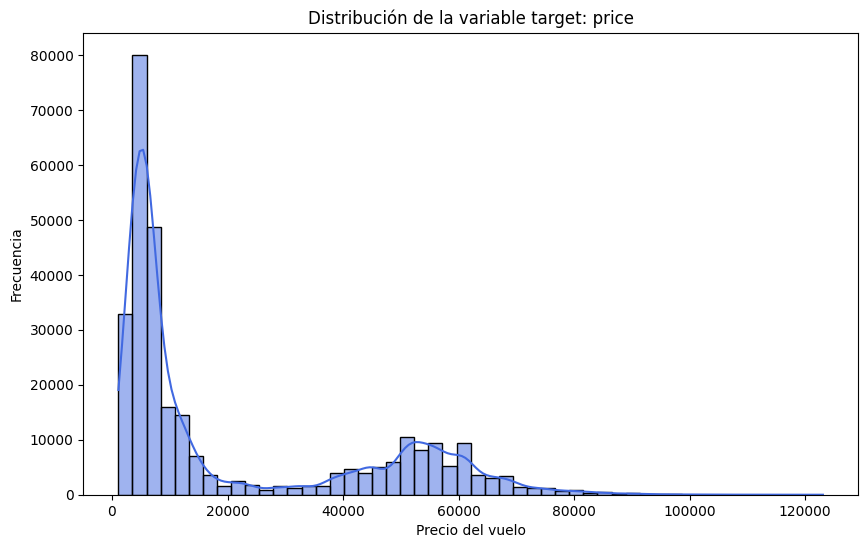

In [89]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final[target_reg], bins=50, kde=True, color='royalblue')
plt.title("Distribución de la variable target: price")
plt.xlabel("Precio del vuelo")
plt.ylabel("Frecuencia")
plt.show()

*'Price' presenta una distribución asimétrica. Hay un pico en valores bajos (clase económica) y una concentración entre 40.000 y 80.000 (que puede ser debido a la clase business). Miro la distribución según la clase:*

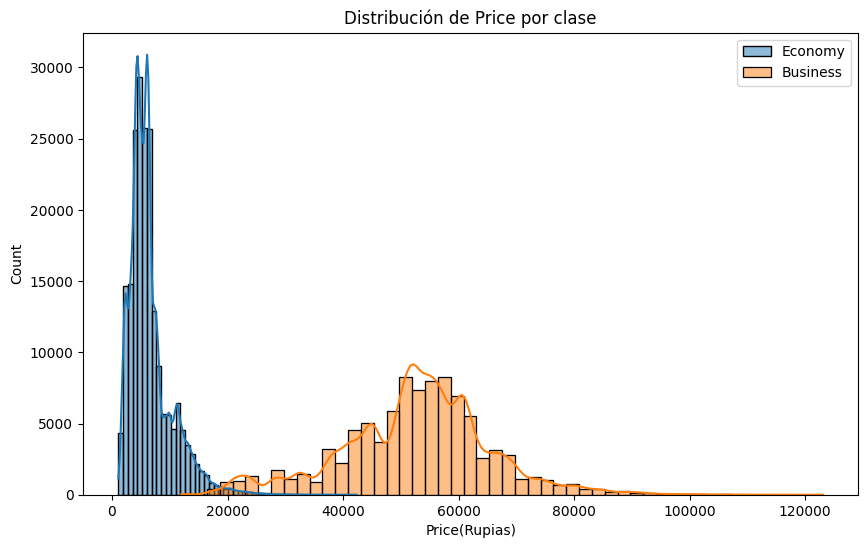

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final[df_final["class"] == "economy"][target_reg], bins=50, kde=True, label = "Economy")
sns.histplot(df_final[df_final["class"] == "business"][target_reg], bins=50, kde=True, label = "Business")
plt.title("Distribución de Price por clase")
plt.xlabel("Price(Rupias)")
plt.legend()
plt.show()

**MINI-EDA**

In [90]:
df_final.columns

Index(['airline', 'source_city', 'destination_city', 'price(Rupias)',
       'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'class',
       'stop_num'],
      dtype='object')

In [89]:
features_num_reg = ["duration(h)", "days_left", "stop_num"]
print(features_num_reg)

features_cat_reg = [col for col in df_final.columns if col not in features_num_reg and col != target_reg]
print(features_cat_reg)

features = features_num_reg + features_cat_reg

['duration(h)', 'days_left', 'stop_num']
['airline', 'source_city', 'destination_city', 'dep_time_cat', 'arr_time_cat', 'class']


Categóricas vs target_reg

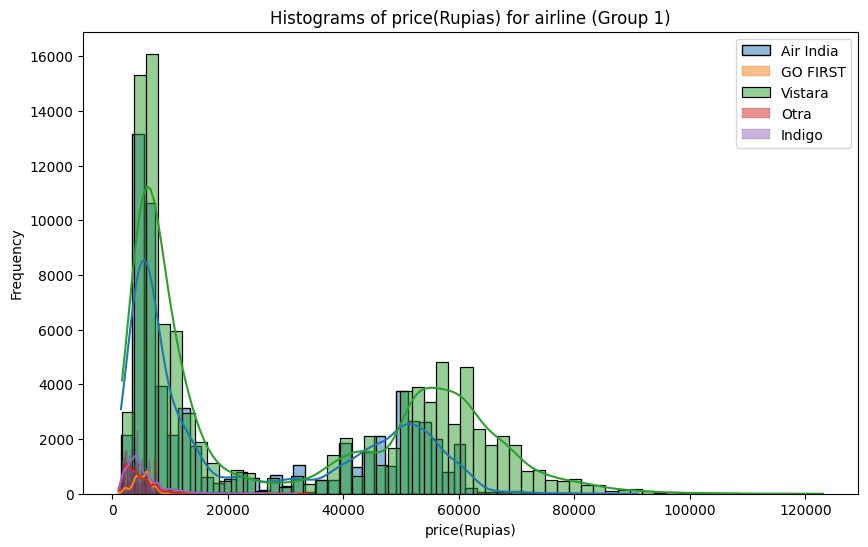

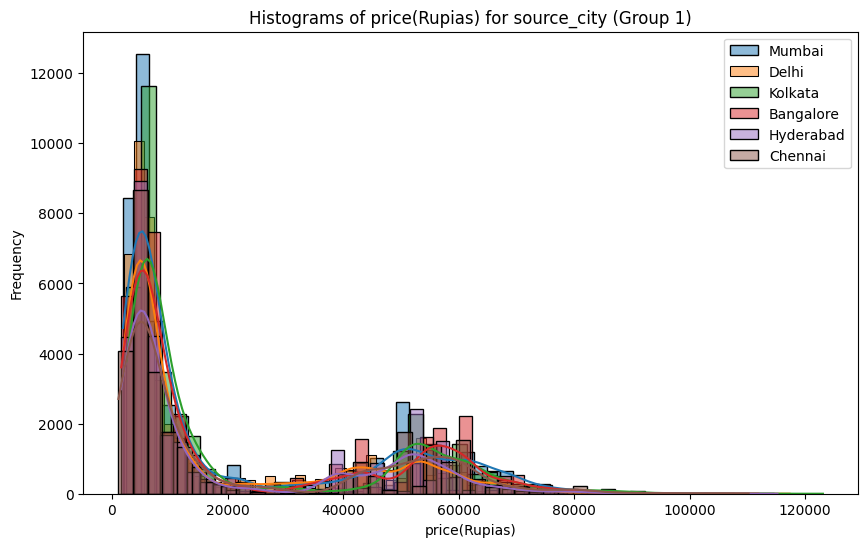

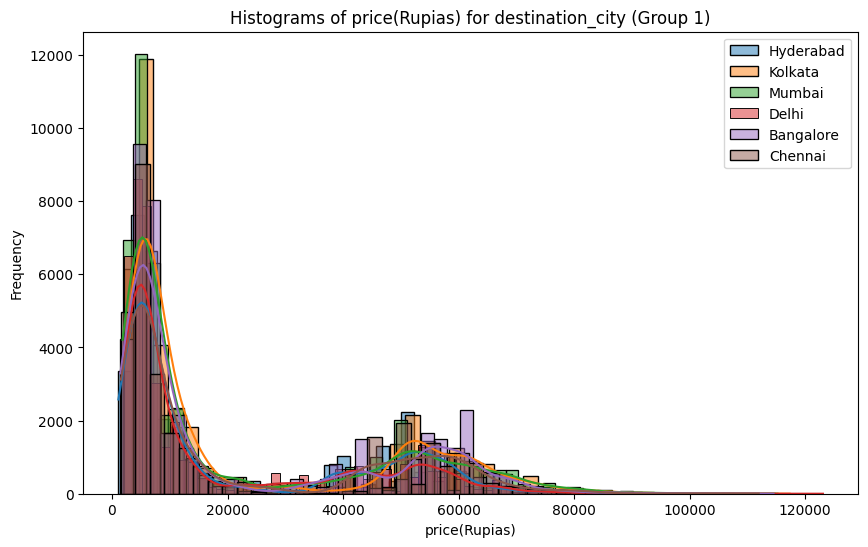

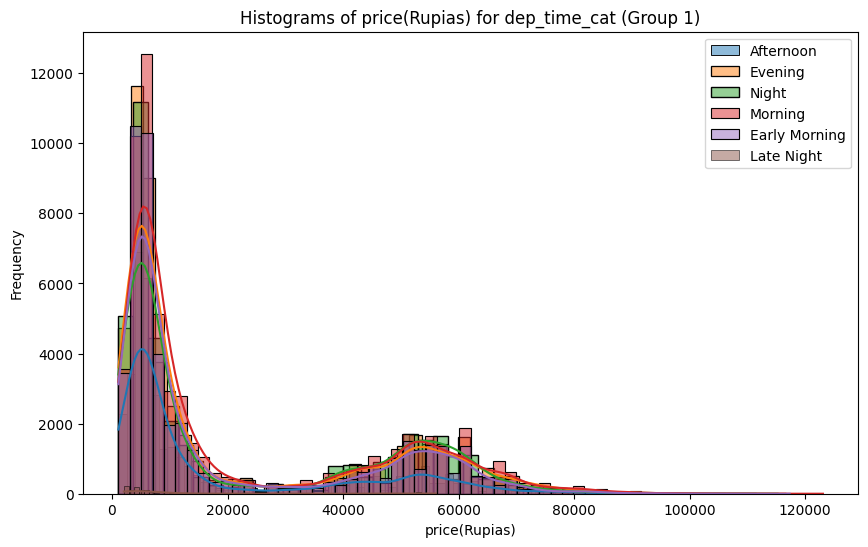

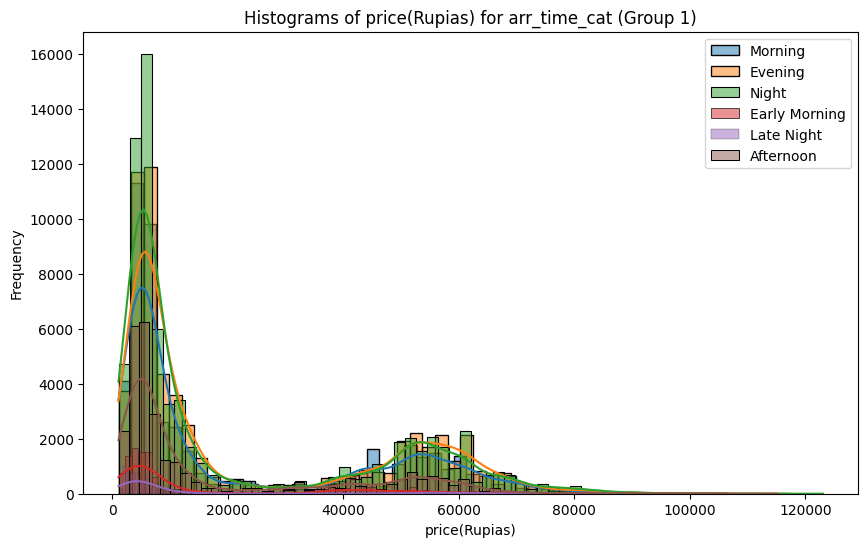

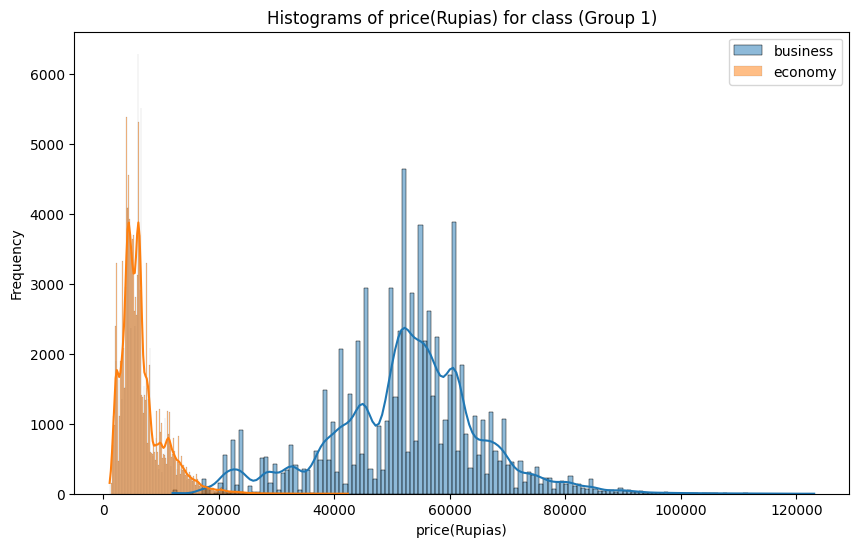

In [92]:
for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(train_set, cat_col= col_cat, num_col= target_reg, group_size= train_set[col_cat].nunique())

*Las distribuciones de 'dep_time_cat' y 'arr_time_cat' son las que más superpuestas parecen*.

Lo hago también con el test ANOVA para decidir si me quedo todas o no.

In [93]:
for cat_col in features_cat_reg:
    valores_unicos = train_set[cat_col].unique()
    target_por_cat_col = [train_set[train_set[cat_col] == categoria][target_reg] for categoria in valores_unicos]

    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

airline:
	 Valor de F: 17081.57235488204
	 p-valor: 0.0
source_city:
	 Valor de F: 111.43991654629089
	 p-valor: 4.913557666382573e-118
destination_city:
	 Valor de F: 142.45408569181038
	 p-valor: 1.8474400472304373e-151
dep_time_cat:
	 Valor de F: 258.3793846974706
	 p-valor: 2.0616262378244465e-276
arr_time_cat:
	 Valor de F: 762.2266222223897
	 p-valor: 0.0
class:
	 Valor de F: 1753340.457890602
	 p-valor: 0.0


*Todos los p-valores son muy pequeños (p-valor < 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que me quedo con todas.*

Numéricas vs target_reg

In [94]:
# Correlaciones
corr = train_set[features_num_reg + [target_reg]].corr()
serie_corr = np.abs(corr[target_reg]).sort_values(ascending = False)
serie_corr

price(Rupias)    1.000000
duration(h)      0.200939
stop_num         0.114994
days_left        0.091964
Name: price(Rupias), dtype: float64

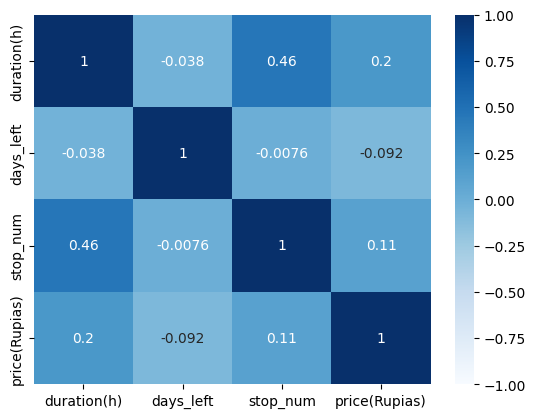

In [95]:
plt.figure()
sns.heatmap(corr, annot= True, cmap = "Blues", vmin= -1, vmax= 1);

- *No correla mucho ninguna variable con el target.*
- *Entre 'stop_num' y 'duration' sí hay cierta colinealidad.*

Como son muy pocas y 0.46 no es mucho, creo que es mejor quedarse con todas.

**Tratamiento de features**

Categóricas

In [96]:
features_cat_reg

['airline',
 'source_city',
 'destination_city',
 'dep_time_cat',
 'arr_time_cat',
 'class']

In [65]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set["class"] = ord_encoder.fit_transform(train_set[["class"]])
test_set["class"] = ord_encoder.transform(test_set[["class"]])

In [66]:
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set[cat_cols])
test_encod = OH_encoder.transform(test_set[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set.index)

In [67]:
resto_cols = [col for col in features if col not in cat_cols]
resto_cols

['duration(h)', 'days_left', 'stop_num', 'class']

In [68]:
train_set = pd.concat([train_set[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set = pd.concat([test_set[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [101]:
print(train_set.shape)
print(test_set.shape)

(238553, 34)
(59639, 34)


In [102]:
train_set.head()

,duration(h),days_left,stop_num,class,price(Rupias),airline_Air India,airline_GO FIRST,airline_Indigo,airline_Otra,airline_Vistara,...,dep_time_cat_Evening,dep_time_cat_Late Night,dep_time_cat_Morning,dep_time_cat_Night,arr_time_cat_Afternoon,arr_time_cat_Early Morning,arr_time_cat_Evening,arr_time_cat_Late Night,arr_time_cat_Morning,arr_time_cat_Night
239454,17.583333,48,1,1.0,45693.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
21379,12.750000,12,1,0.0,5954.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
262332,21.500000,7,1,1.0,50271.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
85586,11.166667,15,1,0.0,10954.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
58841,1.750000,40,0,0.0,2074.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Numéricas

In [103]:
# train_set_scaled = train_set.copy()
# test_set_scaled = test_set.copy()

In [104]:
# train_set[features_num_reg].hist()
# plt.tight_layout()

In [105]:
# train_set["duration(h)"].apply(np.log).hist();

In [106]:
# # Aplico logaritmo a duration
# train_set_scaled["duration(h)"] = np.log(train_set_scaled["duration(h)"])
# test_set_scaled["duration(h)"] = np.log(test_set_scaled["duration(h)"])

Escalado

In [107]:
# scaler = StandardScaler()
# train_set_scaled[features_num_reg] = scaler.fit_transform(train_set_scaled[features_num_reg])
# test_set_scaled[features_num_reg] = scaler.transform(test_set_scaled[features_num_reg])

In [108]:
# train_set_scaled[features_num_reg].describe()

**Modelado**

Parejas X e y

In [107]:
X_train = train_set.drop(columns= target_reg, axis = 1)
# X_train_scaled = train_set_scaled.drop(columns= target_reg, axis = 1)
y_train = train_set[target_reg]

X_test = test_set.drop(columns= target_reg, axis = 1)
# X_test_scaled = test_set_scaled.drop(columns= target_reg, axis = 1)
y_test = test_set[target_reg]

Baseline

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)

Comparación

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 5, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

model_set = [rf_reg, xgb_reg, lgb_reg]

In [119]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train, y_train, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Model <Random Forest>:
	 RMSE_CV: 4358.474523842826
	 MAE_CV: 2418.2658451118746
	 R2-score_CV: 0.9632328439343378
Model <LightGBM>:
	 RMSE_CV: 2575.3553779523227
	 MAE_CV: 1295.5791386706885
	 R2-score_CV: 0.9871630920302332
Model <XGBoost Regressor>:
	 RMSE_CV: 3945.1858538025454
	 MAE_CV: 2341.803115452183
	 R2-score_CV: 0.9698747463915913


*El mejor en todas las métricas es LightGBM*

In [120]:
param_grid_lgb = {
    "n_estimators": [100,200],
    "learning_rate": [0.1,0.5,1],
    "max_depth": [5,10,15],
    "min_data_in_leaf": [1,10,20,100]
}

lgb_reg = LGBMRegressor(verbose = -1)

lgb_grid = GridSearchCV(lgb_reg,
                        param_grid= param_grid_lgb,
                        cv = 5,
                        scoring= "neg_root_mean_squared_error",
                        n_jobs=-1)

lgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(verbose=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.5, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [1, 10, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [121]:
-lgb_grid.best_score_

np.float64(2920.6729414321503)

In [122]:
lgb_grid.best_params_

{'learning_rate': 0.5,
 'max_depth': 15,
 'min_data_in_leaf': 10,
 'n_estimators': 200}

In [124]:
y_pred_test = lgb_grid.best_estimator_.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("R2:", r2_score(y_test, y_pred_test))

RMSE: 2906.9205619190316
MAE: 1653.369112264242
R2: 0.9836332795919495


In [145]:
def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.

    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')

    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()

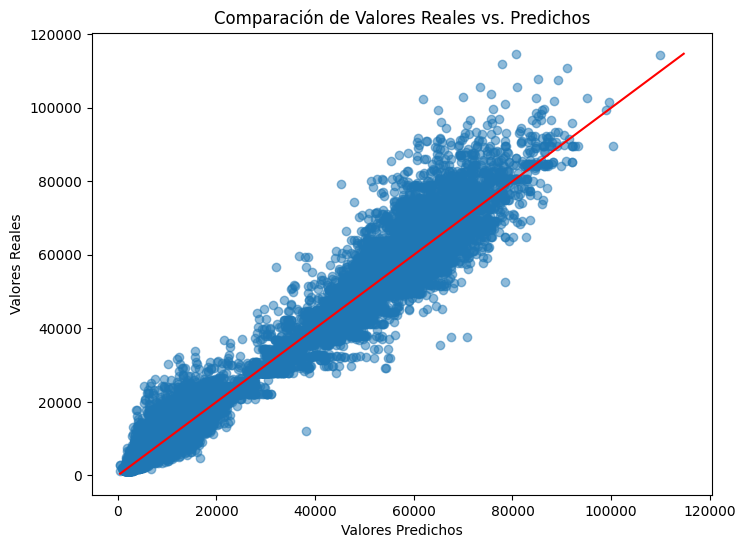

In [111]:
plot_predictions_vs_actual(y_test, y_pred_test)

**Optimización con optuna**

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [105]:
# Crear y ejecutar estudy de Optuna
study = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-02-26 20:22:11,406] A new study created in memory with name: no-name-ed53bb79-2d32-466d-b5d0-2e8162d26557


In [127]:
study.optimize(objective, n_trials= 200) # optimizar el estudio

[I 2026-02-25 11:15:06,984] Trial 0 finished with value: 2679.1336040451724 and parameters: {'n_estimators': 362, 'max_depth': 15, 'num_leaves': 192, 'learning_rate': 0.6187255599871848, 'min_data_in_leaf': 39}. Best is trial 0 with value: 2679.1336040451724.
[I 2026-02-25 11:15:21,308] Trial 1 finished with value: 3431.061472453521 and parameters: {'n_estimators': 209, 'max_depth': 5, 'num_leaves': 227, 'learning_rate': 0.6210592611560484, 'min_data_in_leaf': 145}. Best is trial 0 with value: 2679.1336040451724.
[I 2026-02-25 11:15:39,056] Trial 2 finished with value: 2763.3814526911847 and parameters: {'n_estimators': 114, 'max_depth': 15, 'num_leaves': 218, 'learning_rate': 0.25172215514436236, 'min_data_in_leaf': 44}. Best is trial 0 with value: 2679.1336040451724.
[I 2026-02-25 11:15:55,060] Trial 3 finished with value: 2775.3930370361604 and parameters: {'n_estimators': 228, 'max_depth': 8, 'num_leaves': 140, 'learning_rate': 0.46034776771000996, 'min_data_in_leaf': 65}. Best is 

In [140]:
optuna.visualization.plot_param_importances(study)

In [139]:
study.best_value

2489.336126952272

In [132]:
best_params = study.best_params
best_params

{'n_estimators': 800,
 'max_depth': 15,
 'num_leaves': 244,
 'learning_rate': 0.12429092072713381,
 'min_data_in_leaf': 10}

In [134]:
best_model = LGBMRegressor(**best_params, random_state= 42, verbose = -1)

In [135]:
best_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,244
,max_depth,15
,learning_rate,0.12429092072713381
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [136]:
y_pred = best_model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 2383.622356575259
MAE: 1159.5781742091317
R2: 0.9889955019964942


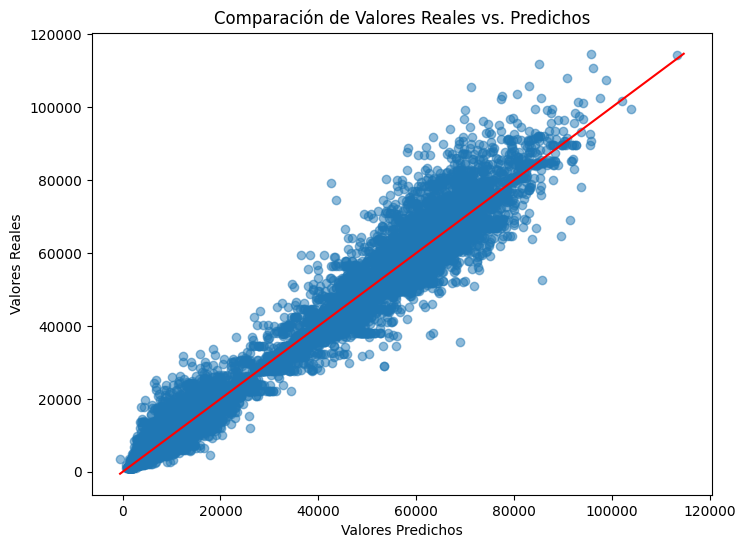

In [146]:
plot_predictions_vs_actual(y_test, y_pred)

Guardo el modelo:

In [74]:
joblib.dump(best_model, "lgbm_best_model.joblib")

NameError: name 'best_model' is not defined

In [97]:
modelo = joblib.load("lgbm_best_model.joblib")

In [111]:
mask_econ = X_train["class"] == 0
mask_bus = X_train["class"] == 1

y_pred = modelo.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train[mask_econ], y_pred[mask_econ]))
print("MAE:", mean_absolute_error(y_train[mask_econ], y_pred[mask_econ]))
print("R2:", r2_score(y_train[mask_econ], y_pred[mask_econ]))

RMSE: 959.1090496130238
MAE: 566.6575441512105
R2: 0.9341490400599268


In [99]:
mask_econ = X_test["class"] == 0
mask_bus = X_test["class"] == 1

y_pred = modelo.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test[mask_econ], y_pred[mask_econ]))
print("MAE:", mean_absolute_error(y_test[mask_econ], y_pred[mask_econ]))
print("R2:", r2_score(y_test[mask_econ], y_pred[mask_econ]))

RMSE: 1356.152713175391
MAE: 742.760479832018
R2: 0.8721959274156338


In [112]:
y_pred = modelo.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train[mask_bus], y_pred[mask_bus]))
print("MAE:", mean_absolute_error(y_train[mask_bus], y_pred[mask_bus]))
print("R2:", r2_score(y_train[mask_bus], y_pred[mask_bus]))

RMSE: 2479.548388278923
MAE: 1392.205745365122
R2: 0.9632240447022992


In [ ]:
# Business
print("RMSE:", root_mean_squared_error(y_test[mask_bus], y_pred[mask_bus]))
print("MAE:", mean_absolute_error(y_test[mask_bus], y_pred[mask_bus]))
print("R2:", r2_score(y_test[mask_bus], y_pred[mask_bus]))

RMSE: 3765.853034519489
MAE: 2081.619233263196
R2: 0.9153923021076397


----

In [ ]:
train_set_eco, test_set_eco = train_test_split(df_eco, test_size= 0.2, random_state= 42)

In [ ]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set_eco["class"] = ord_encoder.fit_transform(train_set_eco[["class"]])
test_set_eco["class"] = ord_encoder.transform(test_set_eco[["class"]])
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set_eco[cat_cols])
test_encod = OH_encoder.transform(test_set_eco[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set_eco.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set_eco.index)
resto_cols = [col for col in features if col not in cat_cols]
resto_cols
train_set_eco = pd.concat([train_set_eco[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set_eco = pd.concat([test_set_eco[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [ ]:
X_train_eco = train_set_eco.drop(columns=target_reg, axis = 1)
X_test_eco = test_set_eco.drop(columns = target_reg, axis = 1)

y_train_eco = train_set_eco[target_reg]
y_test_eco = test_set_eco[target_reg]

In [ ]:
train_set_bus, test_set_bus = train_test_split(df_bus, test_size= 0.2, random_state= 42)

In [ ]:
X_train_bus= train_set_bus.drop(columns=target_reg, axis = 1)
X_test_bus = test_set_bus.drop(columns = target_reg, axis = 1)

y_train_bus = train_set_bus[target_reg]
y_test_bus = test_set_bus[target_reg]

In [ ]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set_bus["class"] = ord_encoder.fit_transform(train_set_bus[["class"]])
test_set_bus["class"] = ord_encoder.transform(test_set_bus[["class"]])
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set_bus[cat_cols])
test_encod = OH_encoder.transform(test_set_bus[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set_bus.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set_bus.index)
resto_cols = [col for col in features if col not in cat_cols]
resto_cols
train_set_bus = pd.concat([train_set_bus[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set_bus = pd.concat([test_set_bus[resto_cols + [target_reg]], test_encod_df], axis = 1)

----

**Con pipeline**

In [101]:
X_train_pipe = train_set_copy.drop(columns= target_reg, axis = 1)
y_train_pipe = train_set_copy[target_reg]

X_test_pipe = test_set_copy.drop(columns= target_reg, axis = 1)
y_test_pipe = test_set_copy[target_reg]

In [105]:
categorias = [["economy", "business"]]
cat_cols = [col for col in features_cat_reg if col != "class"]

preprocesing = ColumnTransformer([
    ("procesar_cat_ord", OrdinalEncoder(categories = categorias, handle_unknown = "use_encoded_value", unknown_value = -1), ["class"]),
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

In [108]:
rf_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", RandomForestRegressor())
])

lgb_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", LGBMRegressor())
])

xgb_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", XGBRegressor())
])

modelos = {
    "rf": rf_pipeline,
    "lgb": lgb_pipeline,
    "xgb": xgb_pipeline
}

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, pipe in modelos.items():
    valores = cross_validate(pipe, X_train_pipe, y_train_pipe, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Optimizar con optuna

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "modelo__n_estimators": trial.suggest_int("modelo__n_estimators", 100, 800),
        "modelo__max_depth": trial.suggest_int("modelo__max_depth", 5, 15),
        "modelo__num_leaves": trial.suggest_int("modelo__num_leaves", 7, 260),
        "modelo__learning_rate": trial.suggest_float("modelo__learning_rate", 0.05, 1),
        "modelo__min_data_in_leaf": trial.suggest_int("modelo__min_data_in_leaf", 10, 200)
    }

    lgb_pipeline.set_params(**param_grid)

    score = cross_val_score(
        lgb_pipeline,
        X_train,
        y_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
study_pipe = optuna.create_study(direction="minimize")
study_pipe.optimize(objective, n_trials=50)

In [ ]:
# Crear y ejecutar estudy de Optuna
study_pipe = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_pipe.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
print(study_pipe.best_value)
best_params_pipe = study_pipe.best_params
best_params_pipe

In [ ]:
best_model_pipe = lgb_pipeline.set_params(**best_params_pipe)

best_model_pipe.fit(X_train_pipe, y_train_pipe)

In [ ]:
joblib.dump(best_model_pipe, "lgbm_best_model_pipe.joblib")

In [ ]:
y_pred = best_model_pipe.predict(X_test_pipe)
print("RMSE:", root_mean_squared_error(y_test_pipe, y_pred))
print("MAE:", mean_absolute_error(y_test_pipe, y_pred))
print("R2:", r2_score(y_test_pipe, y_pred))

----

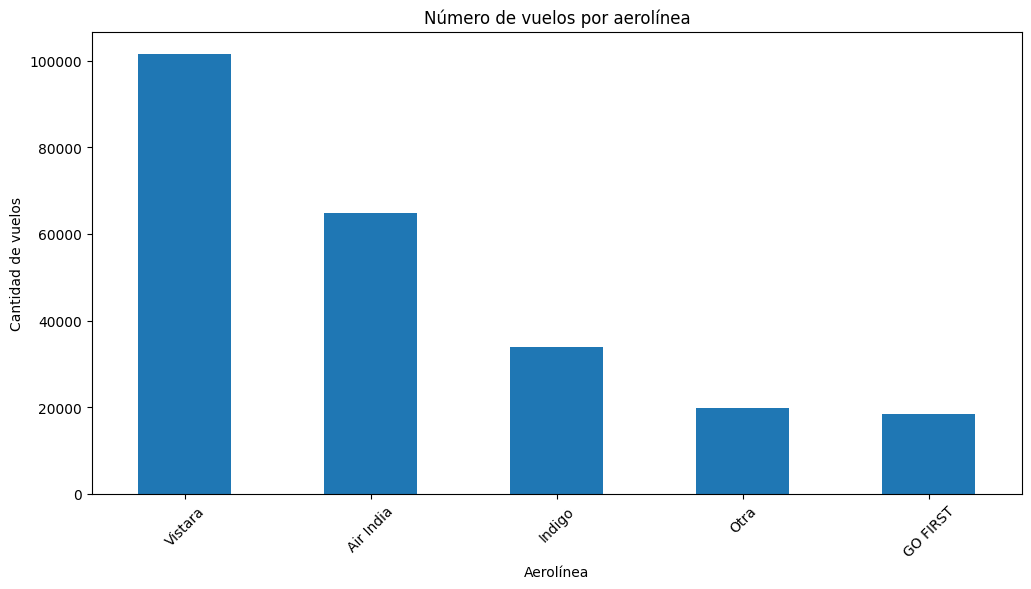

In [289]:
plt.figure(figsize=(12,6))
train_set['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


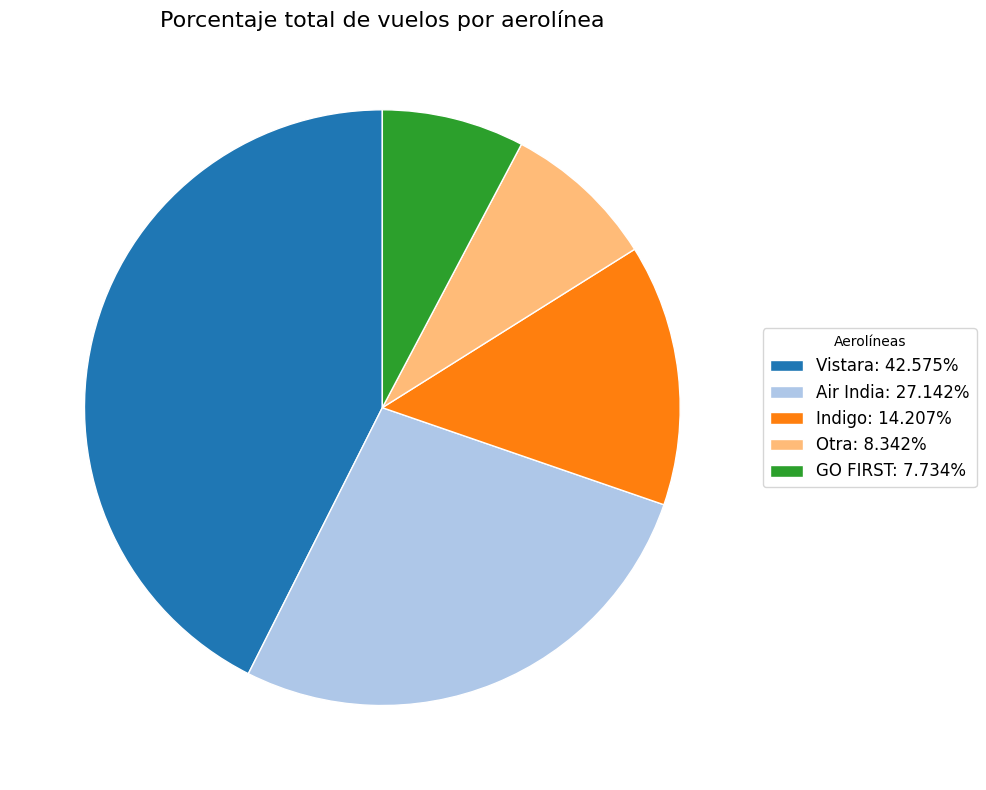

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo y porcentaje
counts = train_set["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea", fontsize=16)
plt.tight_layout()
plt.show()


Ingresos aproximados por aerolínea

In [291]:
train_set.groupby('airline')['price'].sum().sort_values(ascending=False)

airline
Vistara      3.098865e+09
Air India    1.522199e+09
Indigo       1.809659e+08
GO FIRST     1.043377e+08
Otra         9.638645e+07
Name: price, dtype: float64

El dinero esta en rupias 

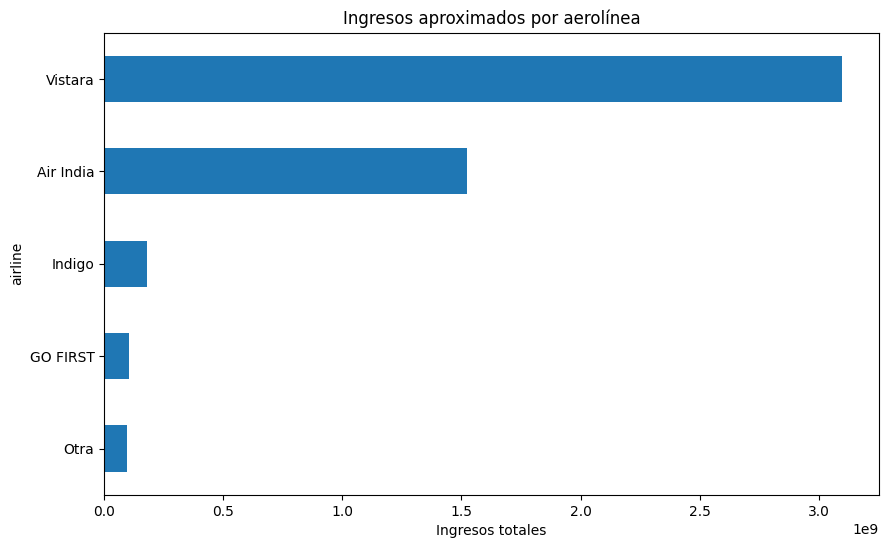

In [292]:
train_set.groupby('airline')['price'].sum().sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Ingresos aproximados por aerolínea")
plt.xlabel("Ingresos totales")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar ingresos por aerolínea y clase
income_class = train_set.groupby(['airline', 'class'])['price'].sum().reset_index()

# Calcular porcentaje dentro de cada aerolínea
income_class['percent'] = income_class.groupby('airline')['price'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=income_class,
    x='airline',
    y='percent',
    hue='class',
    palette='tab10'
)

# Añadir etiquetas de porcentaje encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Porcentaje de ingresos por aerolínea (Economy vs Business)", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje de ingresos (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Porcentaje por aerolinea de vuelos business

C:\Users\lufue\AppData\Local\Temp\ipykernel_17540\4032887624.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


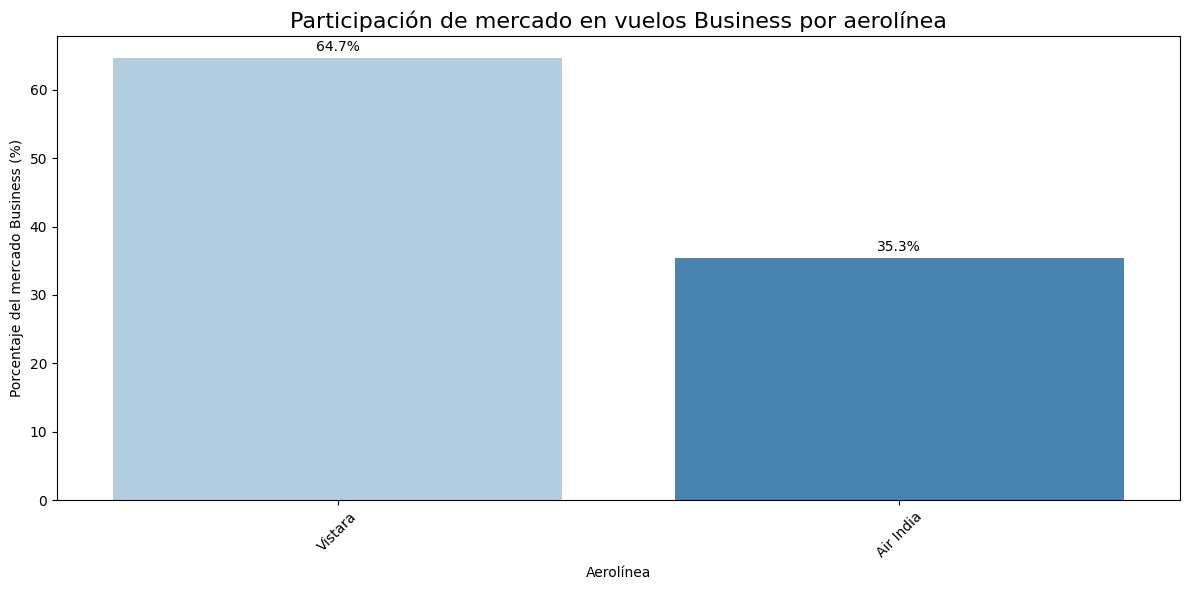

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo vuelos Business
business_df = train_set[train_set['class'] == 'business']

# Contar vuelos business por aerolínea
business_counts = business_df['airline'].value_counts()

# Calcular porcentaje sobre el total del mercado business
business_percent = business_counts / business_counts.sum() * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=business_percent.index,
    y=business_percent.values,
    palette="Blues"
)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Participación de mercado en vuelos Business por aerolínea", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje del mercado Business (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Porcentaje por aerolinea de Economy

C:\Users\lufue\AppData\Local\Temp\ipykernel_17540\1095963594.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


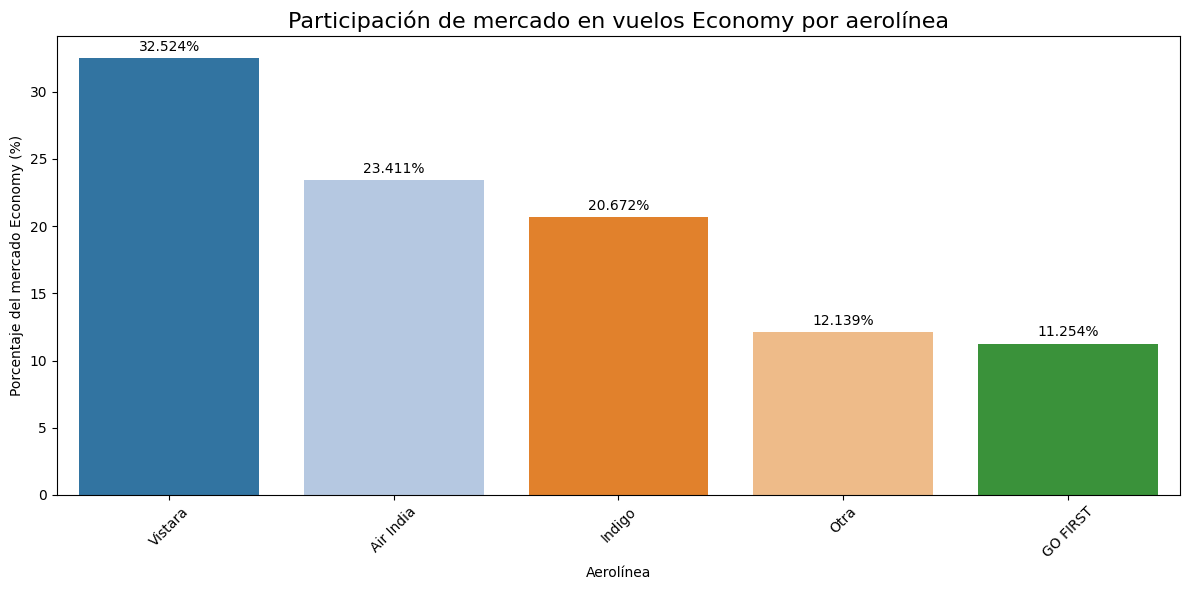

In [295]:
# Paleta igual que el pie chart
colors = sns.color_palette("tab20")

# Orden de aerolíneas según el pie chart
counts = train_set["airline"].value_counts()
airline_order = counts.index.tolist()

# Filtrar solo vuelos Economy
economy_df = train_set[train_set['class'] == 'economy']

# Contar vuelos economy por aerolínea
economy_counts = economy_df['airline'].value_counts()

# Calcular porcentaje sobre el total del mercado economy
economy_percent = economy_counts / economy_counts.sum() * 100

# Alinear colores con el orden del pie chart
economy_colors = [colors[airline_order.index(a)] for a in economy_percent.index]

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=economy_percent.index,
    y=economy_percent.values,
    palette=economy_colors
)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f%%', padding=3)

plt.title("Participación de mercado en vuelos Economy por aerolínea", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje del mercado Economy (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analizando todo esto 

Air India debe ser tu aerolínea
Y te explico por qué es la opción más sólida:

1. Tiene un tamaño grande pero no dominante
- No es tan gigante como Vistara
- No es tan pequeña como Indigo
- Está justo en el medio

2. Tiene mezcla de clases
- 35% del mercado Business
- 23% del mercado Economy
- Ingresos altos pero no extremos
- Esto es perfecto para un modelo de ML porque hay variabilidad real.

3. Tiene rivales claros
- Premium: Vistara
- Low‑cost: Indigo, GO FIRST, AirAsia, SpiceJet
- Tu modelo podrá aprender patrones de ambos mundos.

4. Es la aerolínea más equilibrada del dataset
- Ni demasiado premium
- Ni demasiado low‑cost
- Ni demasiado pequeña
- Ni demasiado dominante

Es la aerolínea “intermedia” ideal para un proyecto académico.

¿Por qué NO incluir StarAir y TruJet?
Tus gráficos muestran:

StarAir:
- 0.02% de los vuelos
- ingresos insignificantes
- casi sin datos
- comportamiento no representativo
- demasiado ruido para un modelo de ML

TruJet:
- 0.014% de los vuelos
- aún menos datos
- no aporta señal
- puede distorsionar el modelo

Son outliers del mercado, no competidores reales de Air India

Qué aerolíneas SÍ incluir?

Estas son las que realmente compiten en el mercado:

Vistara: 
- Rival premium
- Mucho volumen
- Precios altos
- Perfecta para estudiar

GO FIRST:
- Low‑cost
- Competidor directo en rutas económicas

AirAsia
- Low‑cost
- Patrón de precios interesante

SpiceJet
- Low‑cost
- Competidor real en rutas domésticas

In [86]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 217225 entries, 0 to 298208
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           217225 non-null  str    
 1   source_city       217225 non-null  str    
 2   destination_city  217225 non-null  str    
 3   price             217225 non-null  float64
 4   duration          217225 non-null  float64
 5   dep_time_cat      217225 non-null  str    
 6   arr_time_cat      217225 non-null  str    
 7   days_left         217225 non-null  int64  
 8   class             217225 non-null  str    
 9   stop_num          217225 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 18.2 MB


In [87]:
df_ml.describe()

,price,duration,days_left,stop_num
count,217225.000000,217225.000000,217225.000000,217225.000000
mean,20024.419883,11.077931,25.193546,0.916115
std,23304.681420,6.617793,13.488459,0.408854
min,1105.000000,0.833333,0.000000,0.000000
25%,4502.000000,6.333333,14.000000,1.000000
50%,6728.000000,10.083333,25.000000,1.000000
75%,38099.000000,14.500000,37.000000,1.000000
max,123071.000000,47.083333,48.000000,2.000000


Matriz de correlacion 

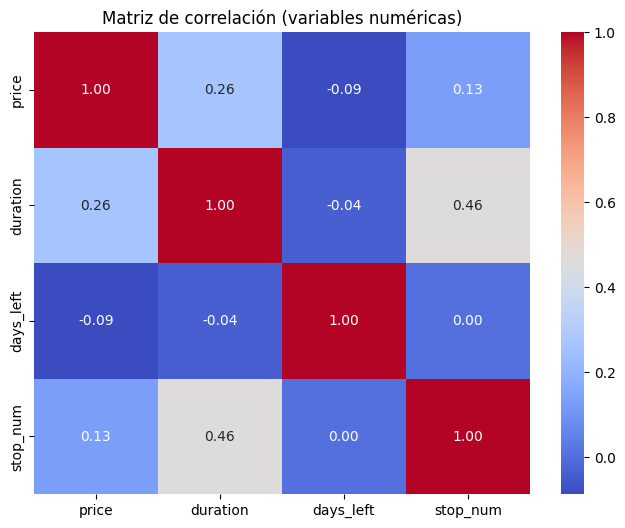

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
num_cols = ['price', 'duration', 'days_left', 'stop_num']

corr_matrix = df_ml[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


Histograma de la variable target 

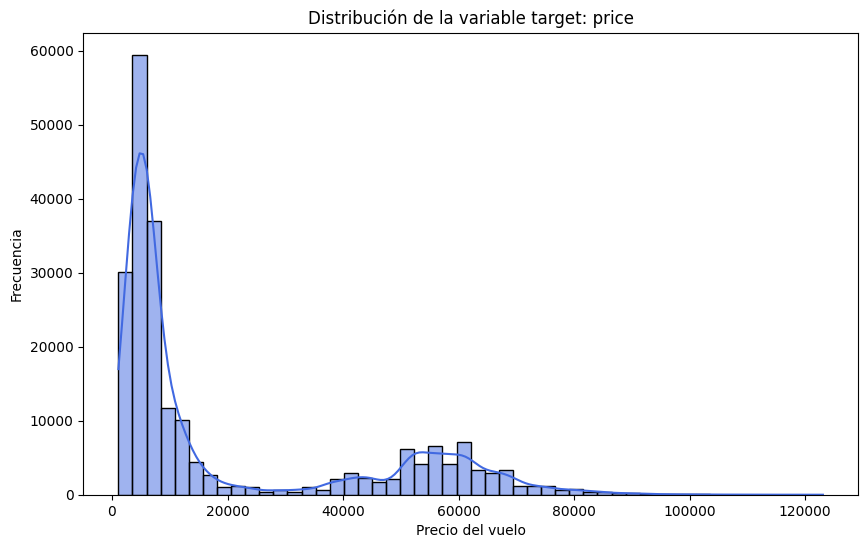

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_ml['price'], bins=50, kde=True, color='royalblue')
plt.title("Distribución de la variable target: price")
plt.xlabel("Precio del vuelo")
plt.ylabel("Frecuencia")
plt.show()


**Machine_Learning**

In [90]:
features_num = ['duration', 'days_left', 'stop_num']

features_cat = [
    'airline',
    'source_city',
    'destination_city',
    'dep_time_cat',
    'arr_time_cat',
    'class'
]



In [91]:
from sklearn.model_selection import train_test_split

X = df_ml[features_num + features_cat]
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
'''from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', StandardScaler(), features_num)
    ]
)'''


PIPELINE 1 — Modelos lineales (OneHot + StandardScaler)

In [92]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', StandardScaler(), features_num)
    ]
)


PIPELINE 2 — Modelos de árboles (OneHot + numéricas sin tocar)

In [ ]:
'''preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', 'passthrough', features_num)
    ]
)'''


In [93]:
from sklearn.preprocessing import OrdinalEncoder

preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), features_cat),
        ('num', 'passthrough', features_num)
    ]
)


PIPELINE 3 — CatBoost (sin preprocesamiento)

In [94]:
from catboost import CatBoostRegressor

model_cat = CatBoostRegressor(
    depth=8,
    learning_rate=0.05,
    iterations=600,
    loss_function="RMSE",
    verbose=0,
    random_state=42
)


In [95]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)


BLOQUE 1 — Modelos lineales

In [96]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

models_linear = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_linear = {}

for name, reg in models_linear.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_linear[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")



📌 LinearRegression
   RMSE CV: 6704.70
   MAE  CV: 4256.78
   R²   CV: 0.9171

📌 Ridge
   RMSE CV: 6704.70
   MAE  CV: 4256.65
   R²   CV: 0.9171

📌 Lasso
   RMSE CV: 6704.72
   MAE  CV: 4254.87
   R²   CV: 0.9171


BLOQUE 2 — Modelos de árboles

In [97]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_trees = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
}

results_trees = {}

for name, reg in models_trees.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_trees),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_trees[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")



📌 RandomForest
   RMSE CV: 3028.55
   MAE  CV: 1247.54
   R²   CV: 0.9831

📌 XGBoost
   RMSE CV: 3737.24
   MAE  CV: 2118.54
   R²   CV: 0.9742

📌 LightGBM
   RMSE CV: 3633.81
   MAE  CV: 2112.41
   R²   CV: 0.9756


BLOQUE 3 — CatBoost (sin preprocesador)

In [98]:
results_cat = {}

rmse = -cross_val_score(model_cat, X_train, y_train,
                        scoring='neg_root_mean_squared_error',
                        cv=5, n_jobs=-1).mean()

mae  = -cross_val_score(model_cat, X_train, y_train,
                        scoring=mae_scorer,
                        cv=5, n_jobs=-1).mean()

r2   =  cross_val_score(model_cat, X_train, y_train,
                        scoring=r2_scorer,
                        cv=5, n_jobs=-1).mean()

results_cat["CatBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

print(f"\n📌 CatBoost")
print(f"   RMSE CV: {rmse:.2f}")
print(f"   MAE  CV: {mae:.2f}")
print(f"   R²   CV: {r2:.4f}")


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "_catboost.pyx", line 2606, in _catboost.get_float_feature
  File "_catboost.pyx", line 1290, in _catboost._FloatOrNan
  File "_catboost.pyx", line 1039, in _catboost._FloatOrNanFromString
TypeError: Cannot convert 'Vistara' to float

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 2701, in _fit
    train_params = self._prepare_train_params(
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 2581, in _prepare_train_params
    train_pool = _build_train_pool(X, y, cat_features, text_features, embedding_features, pairs, graph,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 1540, in _build_train_pool
    train_pool = Pool(X, y, cat_features=cat_features, text_features=text_features, embedding_features=embedding_features, pairs=pairs, graph=graph, weight=sample_weight, group_id=group_id,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 863, in __init__
    self._init(data, label, cat_features, text_features, embedding_features, embedding_features_data, pairs, graph, weight,
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 1518, in _init
    self._init_pool(data, label, cat_features, text_features, embedding_features, embedding_features_data, pairs, graph, weight,
  File "_catboost.pyx", line 4695, in _catboost._PoolBase._init_pool
  File "_catboost.pyx", line 4753, in _catboost._PoolBase._init_pool
  File "_catboost.pyx", line 4541, in _catboost._PoolBase._init_features_order_layout_pool
  File "_catboost.pyx", line 3189, in _catboost._set_features_order_data_pd_data_frame
  File "_catboost.pyx", line 2673, in _catboost.create_num_factor_data
  File "_catboost.pyx", line 2635, in _catboost._set_features_order_data_frame_generic_num_column
  File "_catboost.pyx", line 2608, in _catboost.get_float_feature
_catboost.CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=3]="Vistara": Cannot convert 'Vistara' to float


BLOQUE 1 — Modelos lineales

In [91]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

models_linear = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_linear = {}

for name, reg in models_linear.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_linear[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")



📌 LinearRegression
   RMSE CV: 6704.70
   MAE  CV: 4256.78
   R²   CV: 0.9171

📌 Ridge
   RMSE CV: 6704.70
   MAE  CV: 4256.65
   R²   CV: 0.9171

📌 Lasso
   RMSE CV: 6704.72
   MAE  CV: 4254.87
   R²   CV: 0.9171


BLOQUE 2 — Modelos de árboles

In [92]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_trees = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42
    )
}

results_trees = {}

for name, reg in models_trees.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_trees),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_trees[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")


KeyboardInterrupt: 

BLOQUE 3 — CatBoost (sin preprocesador)

In [ ]:
results_cat = {}

rmse = -cross_val_score(model_cat, X_train, y_train,
                        scoring='neg_root_mean_squared_error',
                        cv=5, n_jobs=-1).mean()

mae  = -cross_val_score(model_cat, X_train, y_train,
                        scoring=mae_scorer,
                        cv=5, n_jobs=-1).mean()

r2   =  cross_val_score(model_cat, X_train, y_train,
                        scoring=r2_scorer,
                        cv=5, n_jobs=-1).mean()

results_cat["CatBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

print(f"\n📌 CatBoost")
print(f"   RMSE CV: {rmse:.2f}")
print(f"   MAE  CV: {mae:.2f}")
print(f"   R²   CV: {r2:.4f}")


In [189]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        depth=8,
        learning_rate=0.05,
        iterations=600,
        loss_function="RMSE",
        verbose=0,
        random_state=42
    )
}


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

results = {}

for name, reg in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', reg)
    ])
    
    # RMSE
    rmse_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=5
    )
    
    # MAE
    mae_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring=mae_scorer,
        cv=5
    )
    
    # R²
    r2_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring=r2_scorer,
        cv=5
    )
    
    results[name] = {
        "RMSE_CV": -rmse_scores.mean(),
        "MAE_CV": -mae_scores.mean(),
        "R2_CV": r2_scores.mean()
    }
    
    print(f"\n📌 Modelo: {name}")
    print(f"   RMSE CV: {-rmse_scores.mean():.2f}")
    print(f"   MAE  CV: {-mae_scores.mean():.2f}")
    print(f"   R²   CV: {r2_scores.mean():.4f}")



📌 Modelo: LinearRegression
   RMSE CV: 6704.70
   MAE  CV: 4256.78
   R²   CV: 0.9171

📌 Modelo: Ridge
   RMSE CV: 6704.70
   MAE  CV: 4256.65
   R²   CV: 0.9171

📌 Modelo: Lasso
   RMSE CV: 6704.72
   MAE  CV: 4254.87
   R²   CV: 0.9171


In [23]:


dup_economy = df_economy[df_economy.duplicated(subset=cols, keep=False)]
dup_business = df_business[df_business.duplicated(subset=cols, keep=False)]

len(dup_economy), len(dup_business)


(70, 0)

In [24]:
df_concat = pd.concat([df_economy, df_business], ignore_index=True)

df_concat_clean = df_concat.drop_duplicates(subset=cols)

df_concat.shape[0] - df_concat_clean.shape[0]


35